In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

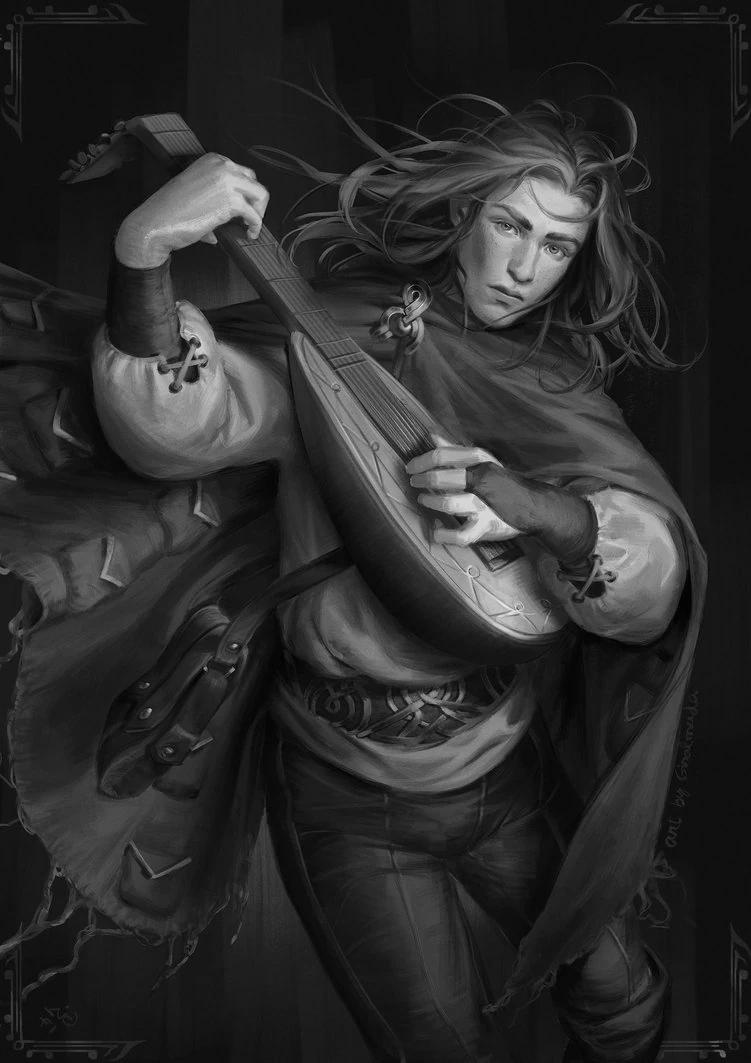

In [4]:
img = Image.open('kvothe.jpg')
grey_img = img.convert('L')
display(grey_img)

In [6]:
grey = np.array(grey_img)
print(grey.shape)

(1063, 751)


In [9]:
# get a middle square of the image
grey = grey[200:600, 200:600]
print(grey.shape)


(200, 200)


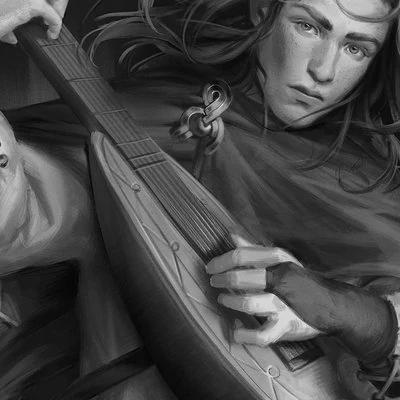

In [8]:
display(Image.fromarray(grey))

In [10]:
# apply 2D wavelet transform
import pywt
coeffs = pywt.dwt2(grey, 'haar')
cA, (cH, cV, cD) = coeffs
print(cA.shape, cH.shape, cV.shape, cD.shape)


(100, 100) (100, 100) (100, 100) (100, 100)


In [15]:
grey


array([[107, 136, 106, ...,  72,  72,  71],
       [ 57,  89, 140, ...,  76,  75,  73],
       [ 59,  52, 114, ...,  82,  79,  76],
       ...,
       [ 16,  16,  17, ...,  59,  70,  78],
       [ 15,  15,  16, ...,  88,  98, 106],
       [ 14,  15,  16, ...,  95, 100, 106]], dtype=uint8)

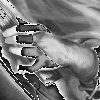

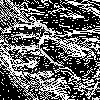

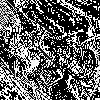

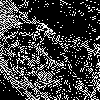

In [21]:
# convert to uint8
cA = cA.astype(np.uint8)
cH = cH.astype(np.uint8)
cV = cV.astype(np.uint8)
cD = cD.astype(np.uint8)

display(Image.fromarray(cA))
display(Image.fromarray(cH))
display(Image.fromarray(cV))
display(Image.fromarray(cD))

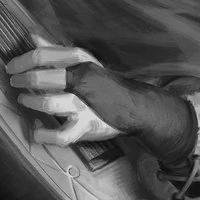

In [42]:
#apply thresholding
T = 50
cA = np.where(cA > T, 255, 0)
cH = np.where(cH > T, 255, 0)
cV = np.where(cV > T, 255, 0)
cD = np.where(cD > T, 255, 0)
ceeffs = cA, (cH, cV, cD) 
grey_reconstructed = pywt.idwt2(coeffs, 'haar')
grey_reconstructed = grey_reconstructed.astype(np.uint8)
display(Image.fromarray(grey_reconstructed))
